# Rolling OTR & Cancel Rate — NIY / NKD (2025)

**Research Axis 1 — Descriptive cross-market microstructure metrics**  
**Date:** 2026-04-02  

---

## Context

NIY (Nikkei 225 Future, JPY-denominated) and NKD (Nikkei 225 Future, USD-denominated) are two futures contracts tracking the **same underlying index** (Nikkei 225) on the **same venue** (CME Globex). They differ only in their denomination currency and contract size. This makes them an ideal pair for microstructure comparison: any behavioral difference between the two cannot be attributed to venue or underlying — it must reflect differences in the **participant base**.

NIY is the primary contract, traded mostly by Japanese institutional participants during the OSE Tokyo session. NKD attracts more USD-based and international participants. NIY dominates in volume (approximately 2.4× more orders, 3.4× more trades than NKD).

## Objective

Analyze the **temporal evolution** of two microstructure metrics over the full year 2025:

- **Order-to-Trade Ratio (OTR)** = `n_add / n_trades` — measures algorithmic quoting intensity. High OTR indicates active market making or quote stuffing; low OTR indicates more directional order flow.
- **Cancel Rate** = `n_cancel / n_add` — measures the fraction of submitted orders that are cancelled before execution. Near 1.0 is characteristic of pure algorithmic market making.

Rolling windows allow us to distinguish:
- **Microstructure regimes**: periods where algorithmic behavior shifts durably (20-day window)
- **Short-term signal**: week-to-week fluctuations in activity (5-day window)
- **NIY/NKD divergences**: if two contracts on the same underlying/venue diverge, it is a signature of participant base dynamics

**Session:** `asia` (OSE Tokyo, 01:00–06:15 UTC) — project cross-market convention.  
**Rolling windows:** 5 days (1 trading week) and 20 days (1 trading month).  
**Period:** full year 2025 (longest available dataset in our universe).

---

## Implementation Notes

- `dr.get_product_stats()` uses DuckDB to aggregate Parquet files in a single SQL pass — RTH bounds are pushed directly into the WHERE clause as nanosecond epoch filters. No tick data is loaded into Python RAM.
- Rolling means are computed via `pandas.rolling()` on the resulting ~250-row daily DataFrame — negligible memory footprint.
- `min_periods=1` is used so early rows are not dropped as NaN. This means the first few values of the rolling 20d series are computed on fewer than 20 observations and should be interpreted with caution.

In [39]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import DestinyResearch as dr
from DestinyResearch.features.descriptive.rolling_stats import (
    add_rolling_metrics,
    merge_products,
    rolling_summary,
)

# --- Output directory for exported figures
FIG_DIR = Path("../../reports/figures/03_rolling_niy_nkd")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Global plot style
sns.set_theme(style="whitegrid", font_scale=1.1)
COLORS = {
    "raw":    "#cccccc",   # light grey — daily raw series
    "roll5":  "#e07b39",   # orange     — 5-day rolling
    "roll20": "#2c5f8a",   # dark blue  — 20-day rolling
}

# --- Parameters
# Change SESSION to 'us' to switch to the CME US session (13:30-20:00 UTC)
SESSION  = "asia"
START    = "2025-01-01"
END      = "2025-12-31"
WINDOWS  = [5, 20]
PRODUCTS = ["NIY", "NKD"]

print(f"Session: {SESSION} | Period: {START} -> {END} | Windows: {WINDOWS}")

Session: asia | Period: 2025-01-01 -> 2025-12-31 | Windows: [5, 20]


## 1. Load Daily Stats

`get_product_stats()` runs a DuckDB glob query over all daily Parquet files in the range.  
RTH filtering (01:00–06:15 UTC for the asia session) is applied inside the SQL query — no full-day data is loaded.  
Result: one ~250-row DataFrame per product. No tick data in RAM.

In [40]:
# Load daily RTH stats for both products — DuckDB handles all file I/O
raw_stats = {}
for product in PRODUCTS:
    df = dr.get_product_stats(product, START, END, schema="mbo", session=SESSION)
    print(f"{product}: {len(df)} trading days loaded")
    raw_stats[product] = df

print("\nColumns:", list(raw_stats[PRODUCTS[0]].columns))

NIY: 258 trading days loaded
NKD: 258 trading days loaded

Columns: ['contract', 'date', 'schema', 'session', 'n_rows', 'n_add', 'n_cancel', 'n_modify', 'n_trade', 'n_fill', 'n_clear', 'cancel_rate', 'fill_rate', 'order_to_trade_ratio', 'price_min', 'price_max', 'price_min_pts', 'price_max_pts', 'price_range_ticks', 'tick_size_pts', 'product']


### Data Quality Notes

- **Sunday files (n_trades = 0):** CME Globex opens Sunday 18:00 ET (23:00 UTC). Databento generates a file for Sunday, but the asia session window (01:00–06:15 UTC Monday JST) falls on Monday — Sunday files contain zero trades in the RTH window. These rows are excluded by `get_product_stats` (filtered on `n_trade > 0`).
- **Cancel rate slightly above 1.0:** Observed on a small number of days (~5 occurrences in 2025). Likely caused by the CME F_SNAPSHOT warmup at stream start: ADD messages injected before the RTH window start time may be cancelled inside the window, producing orphan CANCELs. Same mechanism as EUREX GTC overnight orphans, different root cause. To be investigated on individual days.
- **Thanksgiving spike (2025-11-28):** Cancel rate spikes to ~1.15 on NIY and ~1.08 on NKD. US cash market is closed; OSE asia session runs with very thin participation. The F_SNAPSHOT bootstrap represents an abnormally high fraction of daily events. Structural outlier, not a pipeline bug — kept in the data as-is.

## 2. Compute Rolling Metrics

In [42]:
# Enrich each DataFrame with rolling means for OTR and cancel rate
rolled_stats = {}
for product, df in raw_stats.items():
    rolled_stats[product] = add_rolling_metrics(
        df,
        windows=WINDOWS,
        metrics=["order_to_trade_ratio", "cancel_rate"],
        session=SESSION,
    )

# Long-format merge for seaborn compatibility
merged = merge_products(rolled_stats)
print(f"Merged shape: {merged.shape}")
merged.head(5)

Merged shape: (516, 25)


,contract,date,schema,session,n_rows,n_add,n_cancel,n_modify,n_trade,n_fill,...,price_max,price_min_pts,price_max_pts,price_range_ticks,tick_size_pts,product,order_to_trade_ratio_roll5,order_to_trade_ratio_roll20,cancel_rate_roll5,cancel_rate_roll20
0,NIYH25,2025-01-02,mbo,rth,44207,17947,17946,6387,868,1059,...,39500000000000,39315.0,39500.0,37,5.0,NIY,20.680,20.680,0.999900,0.999900
1,NIYH25,2025-01-03,mbo,rth,74126,31375,31353,9175,964,1259,...,39390000000000,39230.0,39390.0,32,5.0,NIY,26.615,26.615,0.999600,0.999600
2,NIYH25,2025-01-06,mbo,rth,147493,62313,62276,17638,2273,2993,...,39650000000000,39235.0,39650.0,83,5.0,NIY,26.880,26.880,0.999533,0.999533
3,NIYH25,2025-01-07,mbo,rth,164342,67912,67906,20827,3272,4425,...,40310000000000,39910.0,40310.0,80,5.0,NIY,25.350,25.350,0.999625,0.999625
4,NIYH25,2025-01-08,mbo,rth,105070,44087,44053,12739,1854,2337,...,40120000000000,39730.0,40120.0,78,5.0,NIY,25.036,25.036,0.999540,0.999540


## 3. Descriptive Statistics

In [43]:
for product in PRODUCTS:
    print(f"\n{'='*55}")
    print(f"  {product} — OTR summary (session={SESSION})")
    print('='*55)
    print(rolling_summary(rolled_stats[product], "order_to_trade_ratio", windows=WINDOWS))

    print(f"\n  {product} — Cancel rate summary")
    print(rolling_summary(rolled_stats[product], "cancel_rate", windows=WINDOWS))


  NIY — OTR summary (session=asia)
                                  mean        std    min     max
series                                                          
order_to_trade_ratio         35.073798  13.321136  10.93  82.530
order_to_trade_ratio_roll5   34.898136  10.835055  20.68  65.772
order_to_trade_ratio_roll20  34.096212   9.839929  20.68  60.675

  NIY — Cancel rate summary
                        mean       std      min      max
series                                                  
cancel_rate         0.999869  0.009603  0.99200  1.15210
cancel_rate_roll5   0.999870  0.004276  0.99740  1.03008
cancel_rate_roll20  0.999877  0.002146  0.99806  1.00727

  NKD — OTR summary (session=asia)
                                  mean        std        min      max
series                                                               
order_to_trade_ratio         49.820736  21.123471  11.810000  142.100
order_to_trade_ratio_roll5   49.760152  16.266295  21.590000   89.022
order_to_

## 4. Rolling OTR — NIY vs NKD

**Reading guide:**
- **OTR = n_add / n_trades.** High OTR → intense algorithmic quoting (market making, quote stuffing). Low OTR → more directional flow, fewer cancellations per trade.
- **Grey series:** raw daily values — shows day-to-day noise.
- **Orange (5d):** short-term signal — captures week-scale regime shifts.
- **Dark blue (20d):** structural regime — smooths out noise to reveal durable trends.

Saved: ../../reports/figures/03_rolling_niy_nkd/rolling_otr_niy_nkd.png


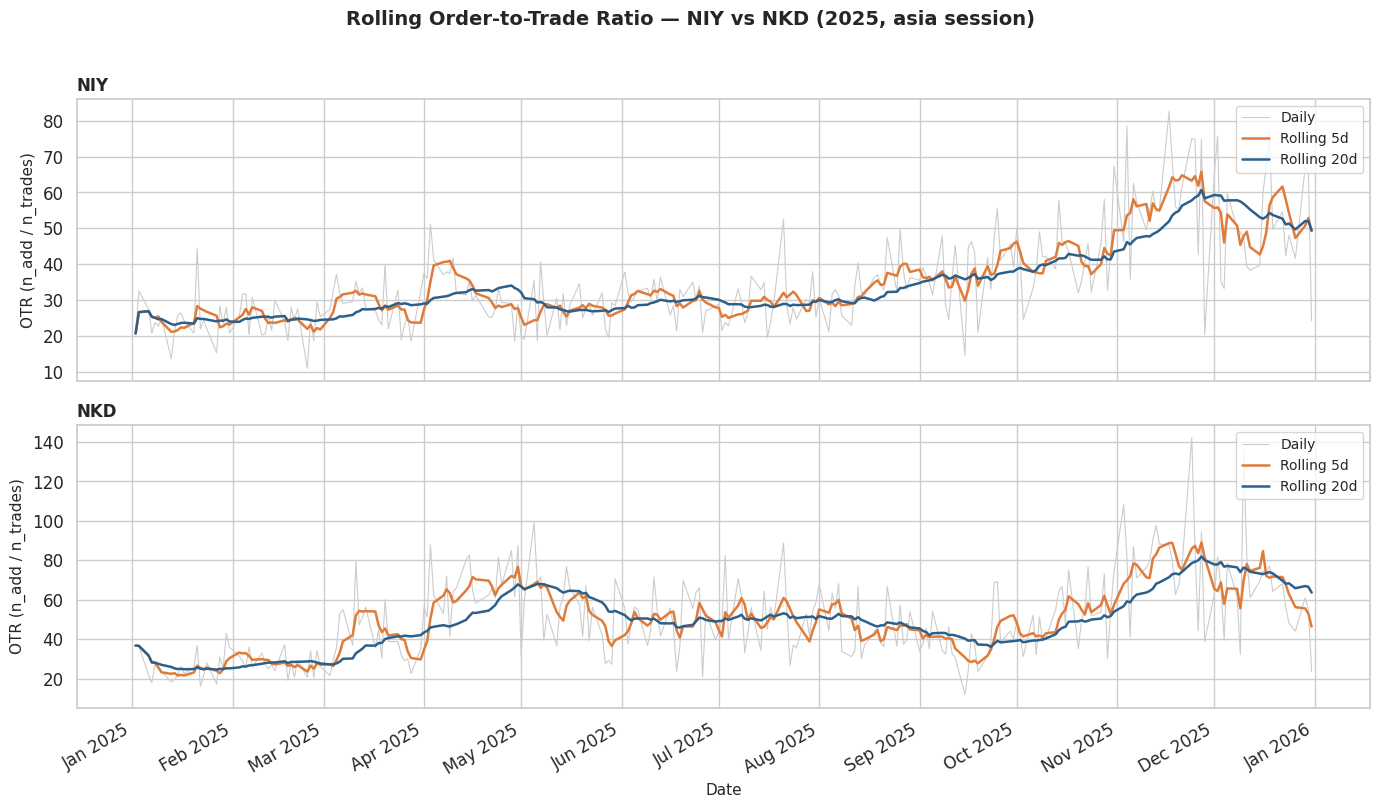

In [44]:
def plot_rolling_metric(
    rolled_stats: dict[str, pd.DataFrame],
    metric: str,
    windows: list[int],
    title: str,
    ylabel: str,
    save_path: Path | None = None,
) -> plt.Figure:
    """Two-panel plot (one per product) of raw daily + rolling series.

    Parameters
    ----------
    rolled_stats : dict — Keys = product tickers, values = DataFrames from add_rolling_metrics().
    metric       : str  — Base metric column name (e.g. 'order_to_trade_ratio').
    windows      : list[int] — Rolling window sizes, must match add_rolling_metrics() call.
    title        : str  — Figure suptitle.
    ylabel       : str  — Y-axis label (shared across panels).
    save_path    : Path — If provided, saves figure as PNG at 300 dpi.
    """
    products = list(rolled_stats.keys())
    n = len(products)

    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, product in zip(axes, products):
        df = rolled_stats[product]

        # Raw daily series — background reference
        ax.plot(df["date"], df[metric],
                color=COLORS["raw"], linewidth=0.8, label="Daily", zorder=1)

        # Rolling windows — signal layers
        roll_colors = [COLORS["roll5"], COLORS["roll20"]]
        for w, color in zip(windows, roll_colors):
            ax.plot(df["date"], df[f"{metric}_roll{w}"],
                    color=color, linewidth=1.8, label=f"Rolling {w}d", zorder=2)

        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(product, fontsize=12, fontweight="bold", loc="left")
        ax.legend(loc="upper right", fontsize=10)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

        # Light vertical lines at month boundaries for readability
        for month_start in pd.date_range(df["date"].min(), df["date"].max(), freq="MS"):
            ax.axvline(month_start, color="#dddddd", linewidth=0.5, zorder=0)

    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    axes[-1].set_xlabel("Date", fontsize=11)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")

    return fig


fig_otr = plot_rolling_metric(
    rolled_stats,
    metric="order_to_trade_ratio",
    windows=WINDOWS,
    title=f"Rolling Order-to-Trade Ratio — NIY vs NKD ({START[:4]}, {SESSION} session)",
    ylabel="OTR (n_add / n_trades)",
    save_path=FIG_DIR / "rolling_otr_niy_nkd.png",
)
plt.show()

## 5. Rolling Cancel Rate — NIY vs NKD

**Reading guide:**
- **Cancel rate = n_cancel / n_add.** Near 1.0 → virtually all submitted orders are cancelled before execution (pure algorithmic market making). Significantly below 1.0 → a non-trivial fraction of orders rests in the book or gets filled.
- Values slightly above 1.0 are possible when the RTH window splits order lifecycles across the session boundary (orphan CANCELs without their matching ADD visible in the window). See data quality notes above.

Saved: ../../reports/figures/03_rolling_niy_nkd/rolling_cancel_rate_niy_nkd.png


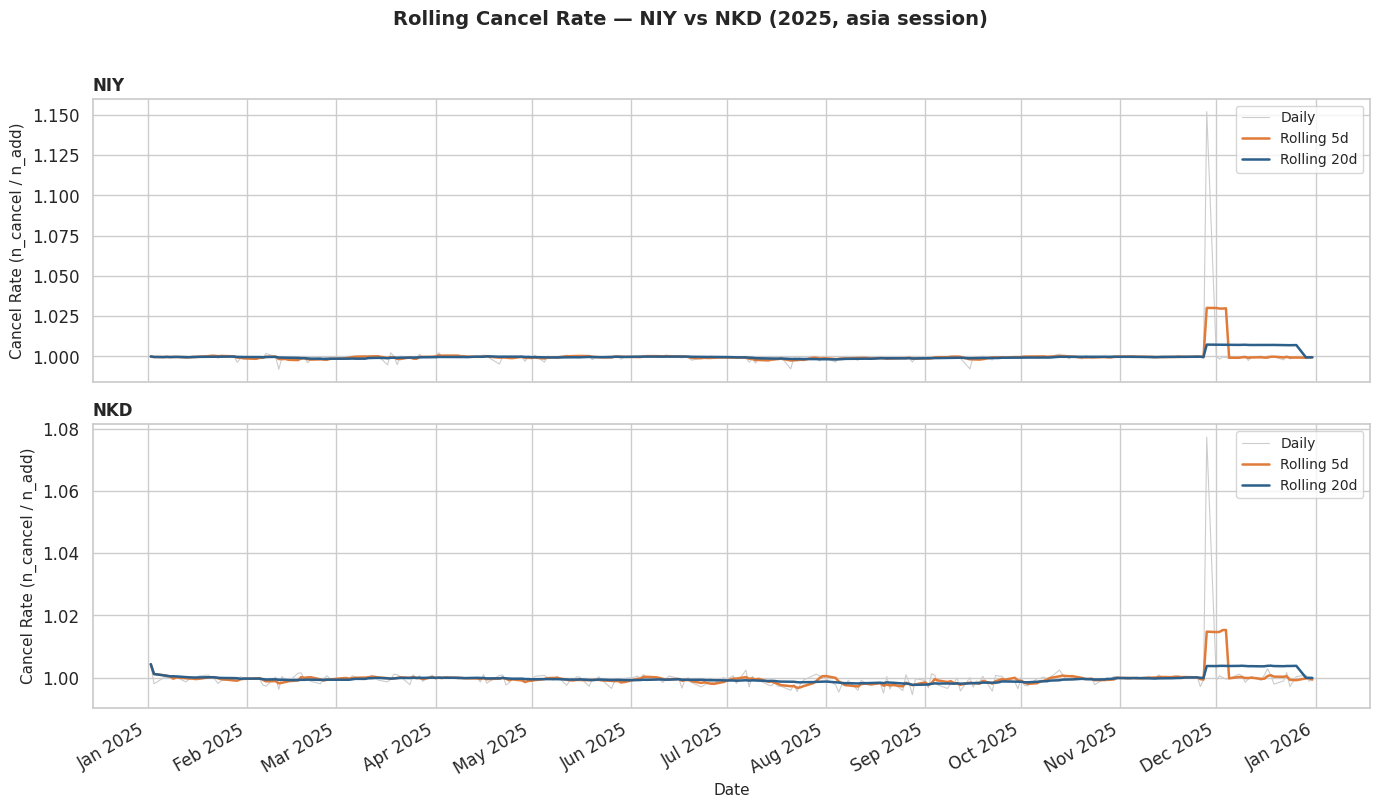

In [45]:
fig_cr = plot_rolling_metric(
    rolled_stats,
    metric="cancel_rate",
    windows=WINDOWS,
    title=f"Rolling Cancel Rate — NIY vs NKD ({START[:4]}, {SESSION} session)",
    ylabel="Cancel Rate (n_cancel / n_add)",
    save_path=FIG_DIR / "rolling_cancel_rate_niy_nkd.png",
)
plt.show()

## 6. OTR Divergence — NIY minus NKD

Since both contracts share the same underlying and venue, their OTR should be correlated. The spread OTR(NIY) − OTR(NKD) isolates the **differential quoting behavior** between JPY-based and USD-based participants.

- **Spread < 0 (NKD > NIY):** USD-denominated participants submit proportionally more orders per trade than JPY participants.
- **Spread > 0 (NIY > NKD):** unusual regime — JPY participants become more algorithmically active than USD participants.
- **Spread near zero:** both participant bases behave similarly.

Common trading days: 258

OTR spread (NIY - NKD) stats:
count    258.00
mean     -14.75
std       16.69
min      -88.67
25%      -24.43
50%      -11.69
75%       -2.47
max       20.84
Name: otr_spread, dtype: float64
Saved: ../../reports/figures/03_rolling_niy_nkd/otr_spread_niy_nkd.png


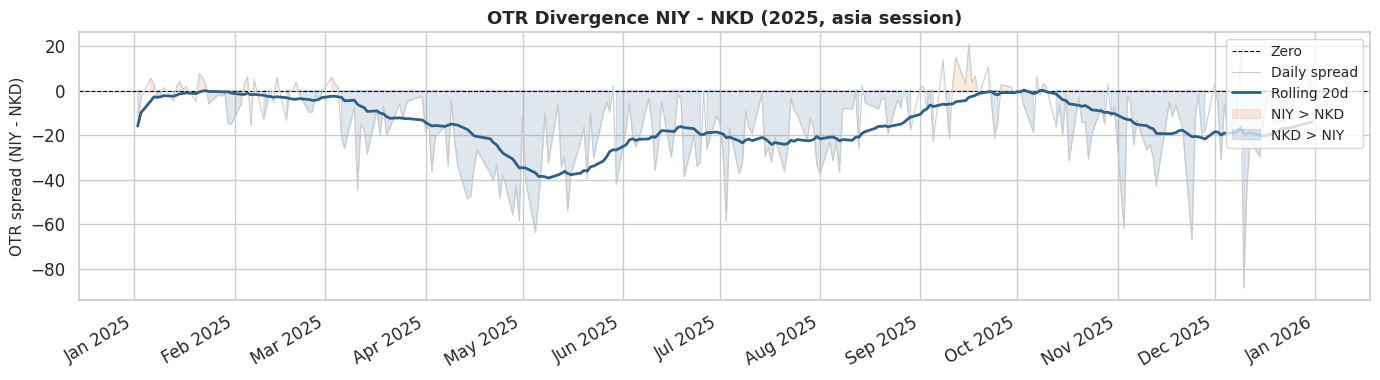

In [46]:
# Align NIY and NKD on date — inner join keeps only common trading days
niy = rolled_stats["NIY"][["date", "order_to_trade_ratio", "order_to_trade_ratio_roll20"]].copy()
nkd = rolled_stats["NKD"][["date", "order_to_trade_ratio", "order_to_trade_ratio_roll20"]].copy()

spread_df = niy.merge(nkd, on="date", suffixes=("_niy", "_nkd"))
spread_df["otr_spread"]        = spread_df["order_to_trade_ratio_niy"] - spread_df["order_to_trade_ratio_nkd"]
spread_df["otr_spread_roll20"] = spread_df["otr_spread"].rolling(20, min_periods=1).mean()

print(f"Common trading days: {len(spread_df)}")
print(f"\nOTR spread (NIY - NKD) stats:")
print(spread_df["otr_spread"].describe().round(2))

# --- Spread plot
fig, ax = plt.subplots(figsize=(14, 4))

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", label="Zero")
ax.plot(spread_df["date"], spread_df["otr_spread"],
        color=COLORS["raw"], linewidth=0.8, label="Daily spread")
ax.plot(spread_df["date"], spread_df["otr_spread_roll20"],
        color=COLORS["roll20"], linewidth=2.0, label="Rolling 20d")

# Shade positive (NIY > NKD) and negative (NKD > NIY) regions
ax.fill_between(spread_df["date"], spread_df["otr_spread"], 0,
                where=spread_df["otr_spread"] > 0,
                alpha=0.15, color=COLORS["roll5"], label="NIY > NKD")
ax.fill_between(spread_df["date"], spread_df["otr_spread"], 0,
                where=spread_df["otr_spread"] < 0,
                alpha=0.15, color=COLORS["roll20"], label="NKD > NIY")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=30, ha="right")

ax.set_ylabel("OTR spread (NIY - NKD)", fontsize=11)
ax.set_title(f"OTR Divergence NIY - NKD ({START[:4]}, {SESSION} session)",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
plt.tight_layout()

fig.savefig(FIG_DIR / "otr_spread_niy_nkd.png", dpi=300, bbox_inches="tight")
print(f"Saved: {FIG_DIR / 'otr_spread_niy_nkd.png'}")
plt.show()

## 7. Findings

### 7.1 OTR — Structural uptrend on both contracts

The OTR on NIY rises from ~25 in January 2025 to ~50–60 in December 2025 — a near-monotonic increase confirmed by the 20-day rolling average. NKD follows the same trend at a structurally higher level (~30–80 vs ~20–60). This is not noise: it reflects a genuine increase in algorithmic quoting activity on the asia session throughout the year.

The most likely driver is the **rise in Nikkei 225 volatility in 2025** (BoJ policy shifts, yen moves). Higher volatility → more frequent quote updates by market makers → higher OTR. This is a well-documented relationship in the microstructure literature.

### 7.2 NKD OTR is structurally higher than NIY

The OTR spread (NIY − NKD) is **quasi-systematically negative** throughout 2025 — NKD always has a higher OTR than NIY. This is a structural property, not a transient divergence. The mechanism is mechanical: NKD has ~3.4× fewer trades per day than NIY (market is thinner), so each trade is relatively rarer → for the same number of ADD events, the ratio is higher. Equivalently, USD-based participants submit proportionally more orders per executed trade than JPY-based participants.

### 7.3 May 2025 divergence peak

The spread reaches its maximum negative value (~−40) in May 2025: NKD's OTR spikes while NIY remains stable. This episode warrants cross-referencing with macro events — likely a USD/JPY stress episode that attracted disproportionate activity from USD-denominated participants on NKD.

### 7.4 October 2025 convergence

The spread briefly rebounds toward zero in October 2025, meaning NIY and NKD behaved more symmetrically. Possible causes: BoJ meeting, change in volatility regime, or liquidity redistribution across the two contracts. To be investigated.

### 7.5 Cancel rate — Stable and near 1.0 on both contracts

Cancel rate remains remarkably stable around 0.999–1.000 on both NIY and NKD throughout the year. NKD shows almost no variance; NIY has slightly more. This confirms that both markets are dominated by **pure algorithmic market making**: virtually all submitted orders are cancelled before execution. The cancel rate appears independent from the OTR trend — it does not increase as OTR rises, suggesting the additional orders in H2 2025 are not more directional, just more numerous.

### 7.6 Microstructure is not stationary

The key takeaway for the research project: **microstructure metrics are not stationary over 12 months**, even for well-established contracts on a mature venue. OTR nearly doubles over the year. Any model trained on January 2025 data will face a structurally different market in December 2025. This motivates the use of rolling regime filters in the Destiny Trading pipeline.

## 8. Open Questions and Next Steps

### Immediate follow-up (within Axis 1)

- **Intraday seasonality:** How does OTR vary within the asia session (01:00–06:15 UTC)? Is the rise in OTR concentrated at the open/close, or uniform across the session? This will feed into the RTH sub-window definition for feature engineering.
- **May 2025 and October 2025 events:** Cross-reference the divergence/convergence episodes with macro calendar (BoJ meetings, US NFP, Fed decisions, USD/JPY moves). If they align, it strengthens the narrative around participant base sensitivity to FX volatility.
- **Cancel rate > 1.0 investigation:** Pick one or two affected days, load the raw MBO stream around the session boundary (23:50–01:10 UTC), and count F_SNAPSHOT ADD events vs same-day CANCELs to confirm the warmup hypothesis.

### Axis 2 — Order Flow Imbalance (next)

The OTR uptrend in H2 2025 is a regime indicator. When we compute OFI and its alpha decay, we should condition the results on OTR regime (low OTR / high OTR) to test whether short-term alpha persists differently across regimes. High OTR → more market making → tighter spreads → faster alpha decay? This is a testable hypothesis.

### Longer term

- **Extend to US session (session='us'):** Run the same analysis on the CME US session (13:30–20:00 UTC) for NIY/NKD. The OTR regime is expected to be very different — US session has more directional institutional flow. Comparing asia vs us sessions is a contribution angle for the research paper.
- **Cross-market OTR comparison:** Once we have a common date period across all products (ES + HKEX May 2025 purchase planned for week of 2026-04-07), compute the rolling OTR on all 10 products and compare regime dynamics. Does HKEX OTR correlate with Nikkei OTR? Does ES OTR lead or lag?
- **OTR as regime filter in Destiny Trading:** Use the 20-day rolling OTR as a conditioning variable for signal generation. Define regime thresholds (e.g., OTR < 30 = low-activity regime, OTR > 50 = high-activity regime) and test whether momentum or mean-reversion signals have different IC profiles across regimes.